# House Prices
## Linear Regression Pipeline

### 1. Load Dataset
* `x`= features (inputs, llike Age, Sex, Pclass, Fare)
* `y`= target (Survived: 0 = no, 1 = yes)

In [11]:
import pandas as pd

titanic = pd.read_csv('datasets/train.csv')
print(titanic.head())
print(titanic.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

### 2. Explore & Proprocess
* Look for missing values and handle them
    * missing values tend to break models and must be handled
* median for numeric, mode for categoricall is a simplle strategy and robust

In [17]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

#### Encoding Categorical features
Since logistic regression can't handle text we convert it to numbers
* `Sex`: male = 1, female = 0
* `Embarked`: C=0, Q=1, S=2


In [18]:
from sklearn.preprocessing import LabelEncoder

titanic['Sex'] = LabelEncoder().fit_transform(titanic['Sex'])
titanic['Embarked'] = LabelEncoder().fit_transform(titanic['Embarked'])

#### Drop irrelevant columns
* These columns are either too messy or not useful for Week 3.
* Later we could engineer features from them if needed

In [19]:
titanic = titanic.drop(columns=['Name', 'Ticket', 'Cabin'])

### Step 3: Define X and y

In [25]:
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

### Step 4: Train/Test Split
* 80% train, 20% test
* Random shuffle (seed = 42) for reproducibility
* Keeps alignment between X and y

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state=42)

### Step 5: Optional Scaling
* Not always required for Logistic Regression, but scaling numeric features (Age, Fare) can help optimization.
* Fit only on training data → prevent data leakage.

`??????`

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 6: Train the Model
* Logistic Regression predicts probabilities → sigmoid function maps outputs between 0 and 1.
* Learning happens by maximizing likelihood, not minimizing squared error.

`What doe .fit do`

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 7: Predict & Evaluate
* Accuracy → fraction of correct predictions
* Confusion Matrix → TP, TN, FP, FN
* Helps you see which type of mistakes the model makes

`predict`:
* In logistic regression, predict first calculates the probability `P(Survived=1∣X)=σ(Xβ)` then it puts it into threshollds at 0.5:
    * `P >= 0.5` => 1 (Survived)
    * `P < 0.5` => 0 (Did not survive)

Evaluation:
* Since we don't use a R^2 we have to see how accurate we were by doing 

    `Accuracy = (Number of correct predictions)/(Total Predictions)`

Confusion Matrix:
* Helps se types of Errors

|          | Pred 0 | Pred 1 |
| -------- | ------ | ------ |
| Actual 0 | TN     | FP     |
| Actual 1 | FN     | TP     |

Where:
* TP (True Positive) → predicted survived, actually survived
* TN (True Negative) → predicted didn’t survive, actually didn’t
* FP (False Positive) → predicted survived, actually didn’t
* FN (False Negative) → predicted didn’t survive, actually did

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]


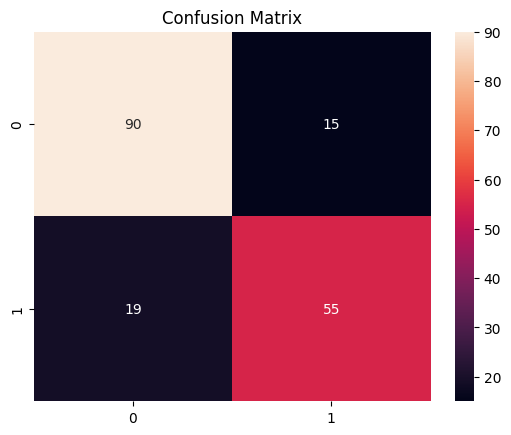

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()